# Task 8: Traffic Sign Recognition
GTSRB Dataset | CNN Multi-class Classification (43 classes)

## 1. Imports

In [8]:
import kagglehub, os, cv2, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
GPU: []


## 2. Load Dataset

In [9]:
import kagglehub, os

path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print("Path:", path)

# Locate CSVs dynamically
train_csv = test_csv = None
for root, dirs, files in os.walk(path):
    for f in files:
        if f == 'Train.csv': train_csv = os.path.join(root, f)
        if f == 'Test.csv':  test_csv  = os.path.join(root, f)

print("Train CSV:", train_csv)
print("Test  CSV:", test_csv)

BASE     = os.path.dirname(train_csv)
train_df = pd.read_csv(train_csv)
test_df  = pd.read_csv(test_csv)

print(f"Train: {len(train_df)} | Test: {len(test_df)} | Classes: {train_df['ClassId'].nunique()}")

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Path: /kaggle/input/gtsrb-german-traffic-sign
Train CSV: /kaggle/input/gtsrb-german-traffic-sign/Train.csv
Test  CSV: /kaggle/input/gtsrb-german-traffic-sign/Test.csv
Train: 39209 | Test: 12630 | Classes: 43


## 3. EDA

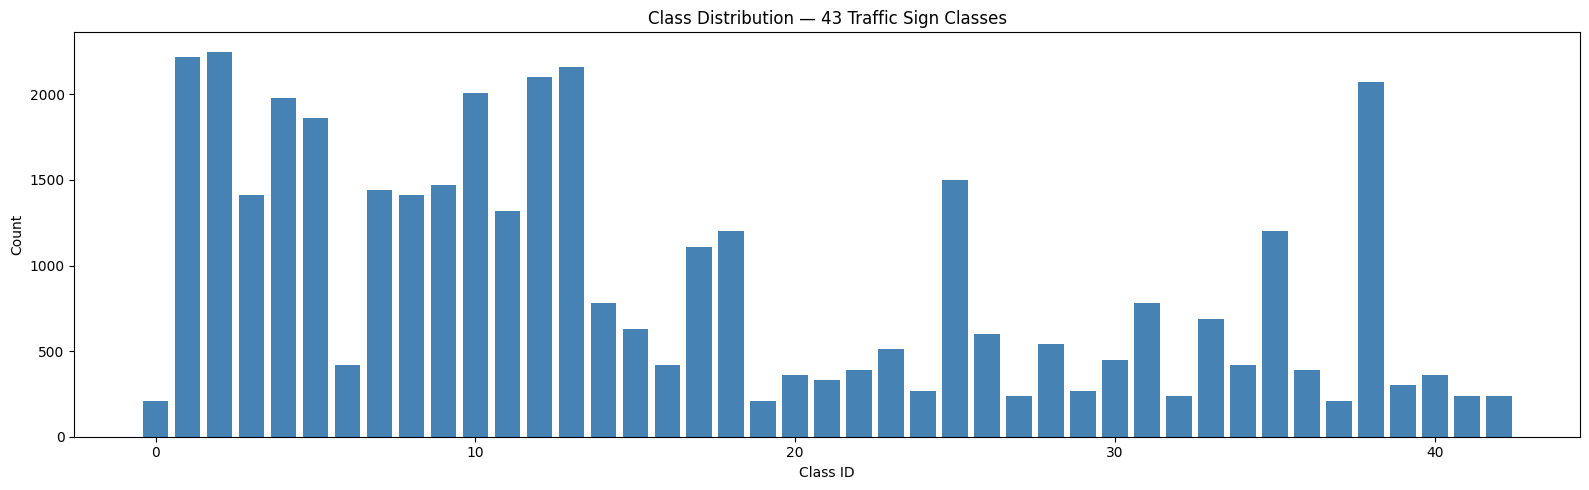

Min: 210 (class 0)  Max: 2250 (class 2)  Ratio: 10x


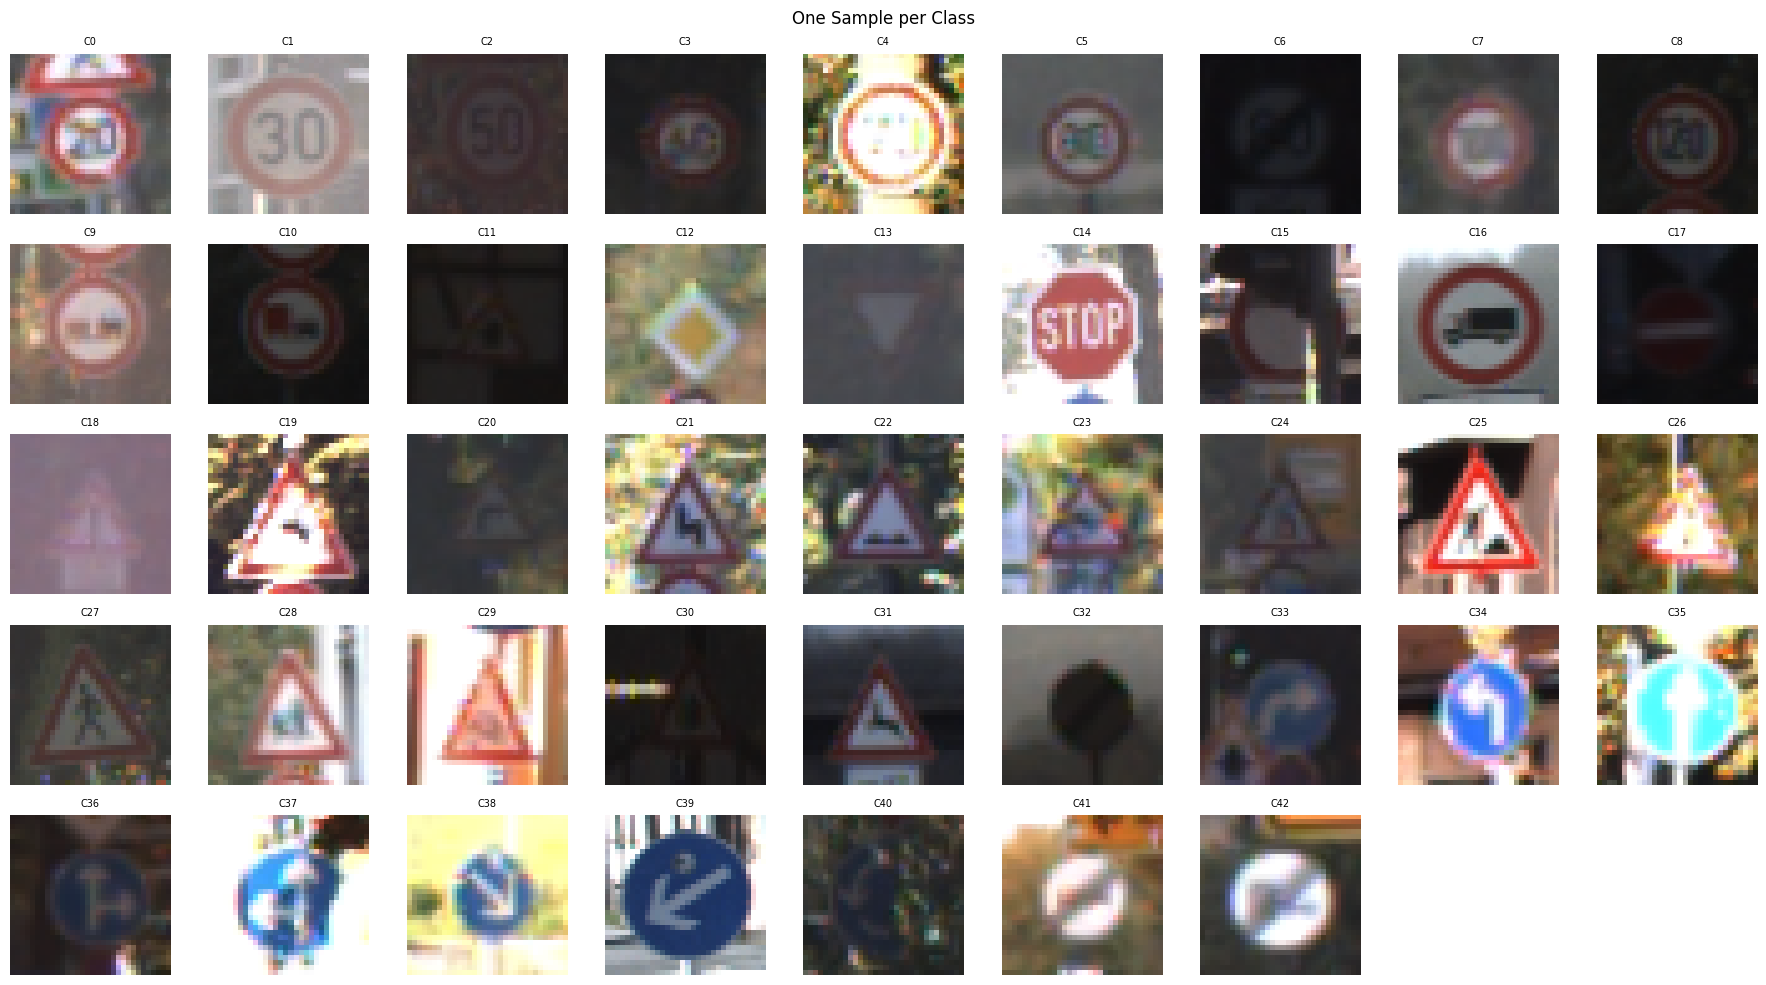

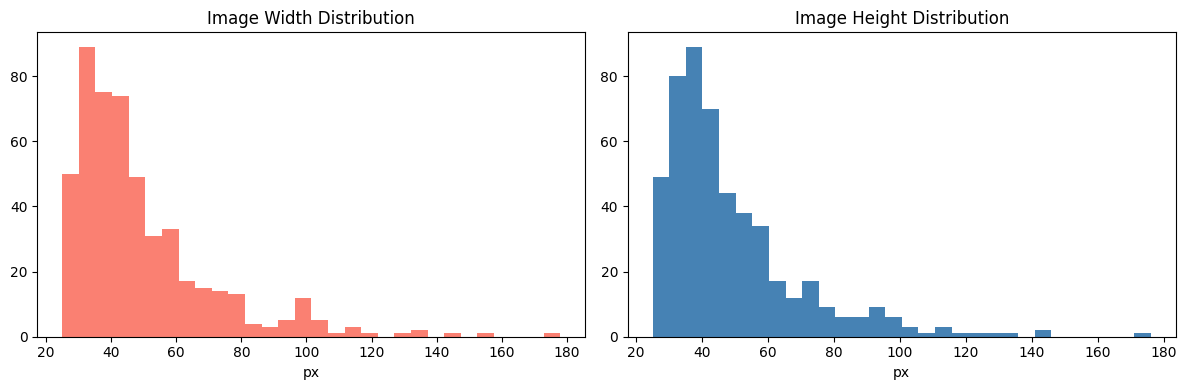

Width  mean:49.3  Height mean:49.0
All images will be resized to 32x32 for training.


In [10]:
counts = train_df['ClassId'].value_counts().sort_index()

plt.figure(figsize=(16,5))
plt.bar(counts.index, counts.values, color='steelblue')
plt.xlabel('Class ID'); plt.ylabel('Count')
plt.title('Class Distribution — 43 Traffic Sign Classes')
plt.tight_layout(); plt.show()

print(f"Min: {counts.min()} (class {counts.idxmin()})  "
      f"Max: {counts.max()} (class {counts.idxmax()})  "
      f"Ratio: {counts.max()//counts.min()}x")

# Sample image per class
fig, axes = plt.subplots(5, 9, figsize=(18,10))
axes = axes.flatten()
for cid in range(43):
    row = train_df[train_df['ClassId']==cid].iloc[0]
    p   = os.path.join(BASE, row['Path'])
    try:
        img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        axes[cid].imshow(cv2.resize(img,(32,32)))
    except: pass
    axes[cid].set_title(f'C{cid}', fontsize=7)
    axes[cid].axis('off')
for i in range(43, len(axes)): axes[i].set_visible(False)
plt.suptitle('One Sample per Class', fontsize=12)
plt.tight_layout(); plt.show()

# Image size distribution
sample = train_df.sample(500, random_state=42)
widths, heights = [], []
for _, row in sample.iterrows():
    img = cv2.imread(os.path.join(BASE, row['Path']))
    if img is not None:
        heights.append(img.shape[0])
        widths.append(img.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(widths,  bins=30, color='salmon')
axes[0].set_title('Image Width Distribution'); axes[0].set_xlabel('px')
axes[1].hist(heights, bins=30, color='steelblue')
axes[1].set_title('Image Height Distribution'); axes[1].set_xlabel('px')
plt.tight_layout(); plt.show()
print(f"Width  mean:{np.mean(widths):.1f}  Height mean:{np.mean(heights):.1f}")
print("All images will be resized to 32x32 for training.")

## 4. Load All Images

In [11]:
NUM_CLASSES = 43

def load_images(df, base, size=32):
    X, y = [], []
    for _, row in df.iterrows():
        p = os.path.join(base, row['Path'])
        try:
            img = cv2.imread(p)
            if img is None: continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (size, size))
            X.append(img)
            y.append(int(row['ClassId']))
        except: pass
    return np.array(X, dtype=np.float32)/255.0, np.array(y, dtype=np.int32)

print("Loading train 32x32..."); X_all32, y_all32 = load_images(train_df, BASE, 32)
print("Loading test  32x32..."); X_test32, y_test32 = load_images(test_df, BASE, 32)
print("Loading train 48x48..."); X_all48, y_all48 = load_images(train_df, BASE, 48)
print("Loading test  48x48..."); X_test48, y_test48 = load_images(test_df, BASE, 48)

print(f"\nX_all32 : {X_all32.shape}  range [{X_all32.min():.2f},{X_all32.max():.2f}]")
print(f"X_test32: {X_test32.shape}")
print(f"X_all48 : {X_all48.shape}")

Loading train 32x32...
Loading test  32x32...
Loading train 48x48...
Loading test  48x48...

X_all32 : (39209, 32, 32, 3)  range [0.00,1.00]
X_test32: (12630, 32, 32, 3)
X_all48 : (39209, 48, 48, 3)


## 5. Train / Val Split & One-Hot Encoding

In [12]:
y32_cat      = keras.utils.to_categorical(y_all32,  NUM_CLASSES)
y_test32_cat = keras.utils.to_categorical(y_test32, NUM_CLASSES)
y48_cat      = keras.utils.to_categorical(y_all48,  NUM_CLASSES)
y_test48_cat = keras.utils.to_categorical(y_test48, NUM_CLASSES)

X_tr32, X_v32, y_tr32, y_v32 = train_test_split(
    X_all32, y32_cat, test_size=0.2, random_state=42, stratify=y_all32)

X_tr48, X_v48, y_tr48, y_v48 = train_test_split(
    X_all48, y48_cat, test_size=0.2, random_state=42, stratify=y_all48)

print("32x32  Train:", X_tr32.shape, "| Val:", X_v32.shape, "| Test:", X_test32.shape)
print("48x48  Train:", X_tr48.shape, "| Val:", X_v48.shape, "| Test:", X_test48.shape)
print("Labels Train:", y_tr32.shape, "| sum per row:", y_tr32.sum(axis=1)[:5])  # should all be 1

32x32  Train: (31367, 32, 32, 3) | Val: (7842, 32, 32, 3) | Test: (12630, 32, 32, 3)
48x48  Train: (31367, 48, 48, 3) | Val: (7842, 48, 48, 3) | Test: (12630, 48, 48, 3)
Labels Train: (31367, 43) | sum per row: [1. 1. 1. 1. 1.]


## 6. Data Augmentation Helper (numpy, no Keras layer)

In [13]:
# Safe numpy augmentation — works on ALL TF versions
# Applied only at training time via a tf.data pipeline

def augment(image, label):
    """Augment a single (H,W,3) float32 image."""
    # Random left-right flip  — DISABLED for traffic signs (direction-specific)
    # Random rotation ±15 degrees
    if tf.random.uniform(()) > 0.5:
        angle = tf.random.uniform((), -0.26, 0.26)   # radians ~15 deg
        image = tf.keras.preprocessing.image.apply_affine_transform(
            image.numpy(), theta=angle * 57.3, fill_mode='nearest')
        image = tf.cast(image, tf.float32)
    # Random brightness ±20%
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.clip_by_value(image, 0.0, 1.0)
    # Random contrast
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

# Build tf.data pipelines
BATCH   = 64
AUTOTUNE = tf.data.AUTOTUNE

def make_train_ds(X, y, batch=BATCH):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    ds = ds.shuffle(len(X), seed=42)
    # Simple augmentation without rotation (avoids tf.py_function complexity)
    ds = ds.map(lambda x, y: (
        tf.clip_by_value(tf.image.random_brightness(
            tf.image.random_contrast(x, 0.8, 1.2), 0.2), 0.0, 1.0), y),
        num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch).prefetch(AUTOTUNE)
    return ds

def make_val_ds(X, y, batch=BATCH):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    ds = ds.batch(batch).prefetch(AUTOTUNE)
    return ds

train_ds32 = make_train_ds(X_tr32, y_tr32)
val_ds32   = make_val_ds(X_v32,   y_v32)
train_ds48 = make_train_ds(X_tr48, y_tr48)
val_ds48   = make_val_ds(X_v48,   y_v48)

print("tf.data pipelines ready.")

# Sanity check: peek at one batch
for xb, yb in train_ds32.take(1):
    print(f"Batch X: {xb.shape}  range [{xb.numpy().min():.2f},{xb.numpy().max():.2f}]")
    print(f"Batch y: {yb.shape}  row sums (should all be 1): {yb.numpy().sum(axis=1)[:5]}")

tf.data pipelines ready.
Batch X: (64, 32, 32, 3)  range [0.00,1.00]
Batch y: (64, 43)  row sums (should all be 1): [1. 1. 1. 1. 1.]


## 7. Model Definitions

In [14]:
CALLBACKS = [
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
]

def build_baseline(num_classes=43):
    model = keras.Sequential([
        keras.Input(shape=(32,32,3)),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax'),
    ], name='Baseline_CNN')
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_deep(num_classes=43):
    model = keras.Sequential([
        keras.Input(shape=(32,32,3)),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax'),
    ], name='Deep_CNN')
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_mobilenet(num_classes=43):
    base = MobileNetV2(weights='imagenet', include_top=False,
                       input_shape=(48,48,3))
    base.trainable = False
    inp = keras.Input(shape=(48,48,3))
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    m   = Model(inp, out, name='MobileNetV2')
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy', metrics=['accuracy'])
    return m

print("Models defined.")
print(f"  Baseline params : {build_baseline().count_params():,}")
print(f"  Deep CNN params : {build_deep().count_params():,}")

Models defined.
  Baseline params : 549,355
  Deep CNN params : 1,213,515


## 8. Train Baseline CNN

In [15]:
baseline = build_baseline()
baseline.summary()

t0 = time.time()
hist_b = baseline.fit(
    train_ds32,
    epochs=25,
    validation_data=val_ds32,
    callbacks=CALLBACKS,
    verbose=1
)
t_b = time.time() - t0

_, acc_b = baseline.evaluate(
    make_val_ds(X_test32, y_test32_cat), verbose=0)
print(f"\nBaseline CNN — Test Accuracy: {acc_b:.4f} | Time: {t_b:.1f}s")

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 549,355 (2.10 MB)

 Trainable params: 549,355 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 63s 122ms/step - accuracy: 0.2431 - loss: 2.8416 - val_accuracy: 0.7942 - val_loss: 0.7931 - learning_rate: 0.0010
Epoch 2/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 82s 124ms/step - accuracy: 0.6691 - loss: 1.0655 - val_accuracy: 0.9324 - val_loss: 0.2949 - learning_rate: 0.0010
Epoch 3/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 83s 125ms/step - accuracy: 0.7906 - loss: 0.6663 - val_accuracy: 0.9583 - val_loss: 0.1898 - learning_rate: 0.0010
Epoch 4/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 85s 131ms/step - accuracy: 0.8322 - loss: 0.5352 - val_accuracy: 0.9703 - val_loss: 0.1215 - learning_rate: 0.0010
Epoch 5/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 62s 126ms/step - accuracy: 0.8648 - loss: 0.4410 - val_accuracy: 0.9804 - val_loss: 0.0964 - learning_rate: 0.0010
Epoch 6/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 60s 121ms/step - accuracy: 0.8738 - loss: 0.3958 - val_accuracy: 0.9809 - val_loss: 0.0883 - learning_rate: 0.0010
Epoch 7/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 84s 125ms/step - accuracy: 0.8

## 9. Train Deep CNN

In [16]:
deep = build_deep()
deep.summary()

t0 = time.time()
hist_d = deep.fit(
    train_ds32,
    epochs=30,
    validation_data=val_ds32,
    callbacks=CALLBACKS,
    verbose=1
)
t_d = time.time() - t0

_, acc_d = deep.evaluate(
    make_val_ds(X_test32, y_test32_cat), verbose=0)
print(f"\nDeep CNN — Test Accuracy: {acc_d:.4f} | Time: {t_d:.1f}s")

Model: "Deep_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,213,515 (4.63 MB)

 Trainable params: 1,212,043 (4.62 MB)

 Non-trainable params: 1,472 (5.75 KB)

Epoch 1/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 256s 510ms/step - accuracy: 0.3116 - loss: 2.8929 - val_accuracy: 0.6807 - val_loss: 1.1690 - learning_rate: 0.0010
Epoch 2/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 260s 506ms/step - accuracy: 0.8524 - loss: 0.4783 - val_accuracy: 0.9704 - val_loss: 0.1109 - learning_rate: 0.0010
Epoch 3/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 268s 518ms/step - accuracy: 0.9341 - loss: 0.2288 - val_accuracy: 0.9943 - val_loss: 0.0244 - learning_rate: 0.0010
Epoch 4/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 260s 513ms/step - accuracy: 0.9530 - loss: 0.1619 - val_accuracy: 0.9948 - val_loss: 0.0196 - learning_rate: 0.0010
Epoch 5/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 251s 511ms/step - accuracy: 0.9606 - loss: 0.1410 - val_accuracy: 0.9857 - val_loss: 0.0440 - learning_rate: 0.0010
Epoch 6/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 260s 507ms/step - accuracy: 0.9575 - loss: 0.1534 - val_accuracy: 0.9966 - val_loss: 0.0164 - learning_rate: 0.0010
Epoch 7/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 275s 533ms/step - accura

## 10. Train MobileNetV2 (Bonus)

In [17]:
mobilenet = build_mobilenet()
mobilenet.summary()

t0 = time.time()
hist_m = mobilenet.fit(
    train_ds48,
    epochs=20,
    validation_data=val_ds48,
    callbacks=CALLBACKS,
    verbose=1
)
t_m = time.time() - t0

_, acc_m = mobilenet.evaluate(
    make_val_ds(X_test48, y_test48_cat), verbose=0)
print(f"\nMobileNetV2 — Test Accuracy: {acc_m:.4f} | Time: {t_m:.1f}s")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,597,995 (9.91 MB)

 Trainable params: 339,499 (1.30 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 108s 204ms/step - accuracy: 0.3578 - loss: 2.5177 - val_accuracy: 0.6396 - val_loss: 1.1399 - learning_rate: 0.0010
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 87s 176ms/step - accuracy: 0.5947 - loss: 1.3228 - val_accuracy: 0.7048 - val_loss: 0.9266 - learning_rate: 0.0010
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 140s 172ms/step - accuracy: 0.6576 - loss: 1.0870 - val_accuracy: 0.7302 - val_loss: 0.8343 - learning_rate: 0.0010
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 84s 171ms/step - accuracy: 0.6917 - loss: 0.9858 - val_accuracy: 0.7645 - val_loss: 0.7376 - learning_rate: 0.0010
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 84s 171ms/step - accuracy: 0.7190 - loss: 0.9004 - val_accuracy: 0.7761 - val_loss: 0.6887 - learning_rate: 0.0010
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 149s 184ms/step - accuracy: 0.7289 - loss: 0.8550 - val_accuracy: 0.7823 - val_loss: 0.6676 - learning_rate: 0.0010
Epoch 7/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 135s 171ms/step - accuracy:

## 11. Training Curves

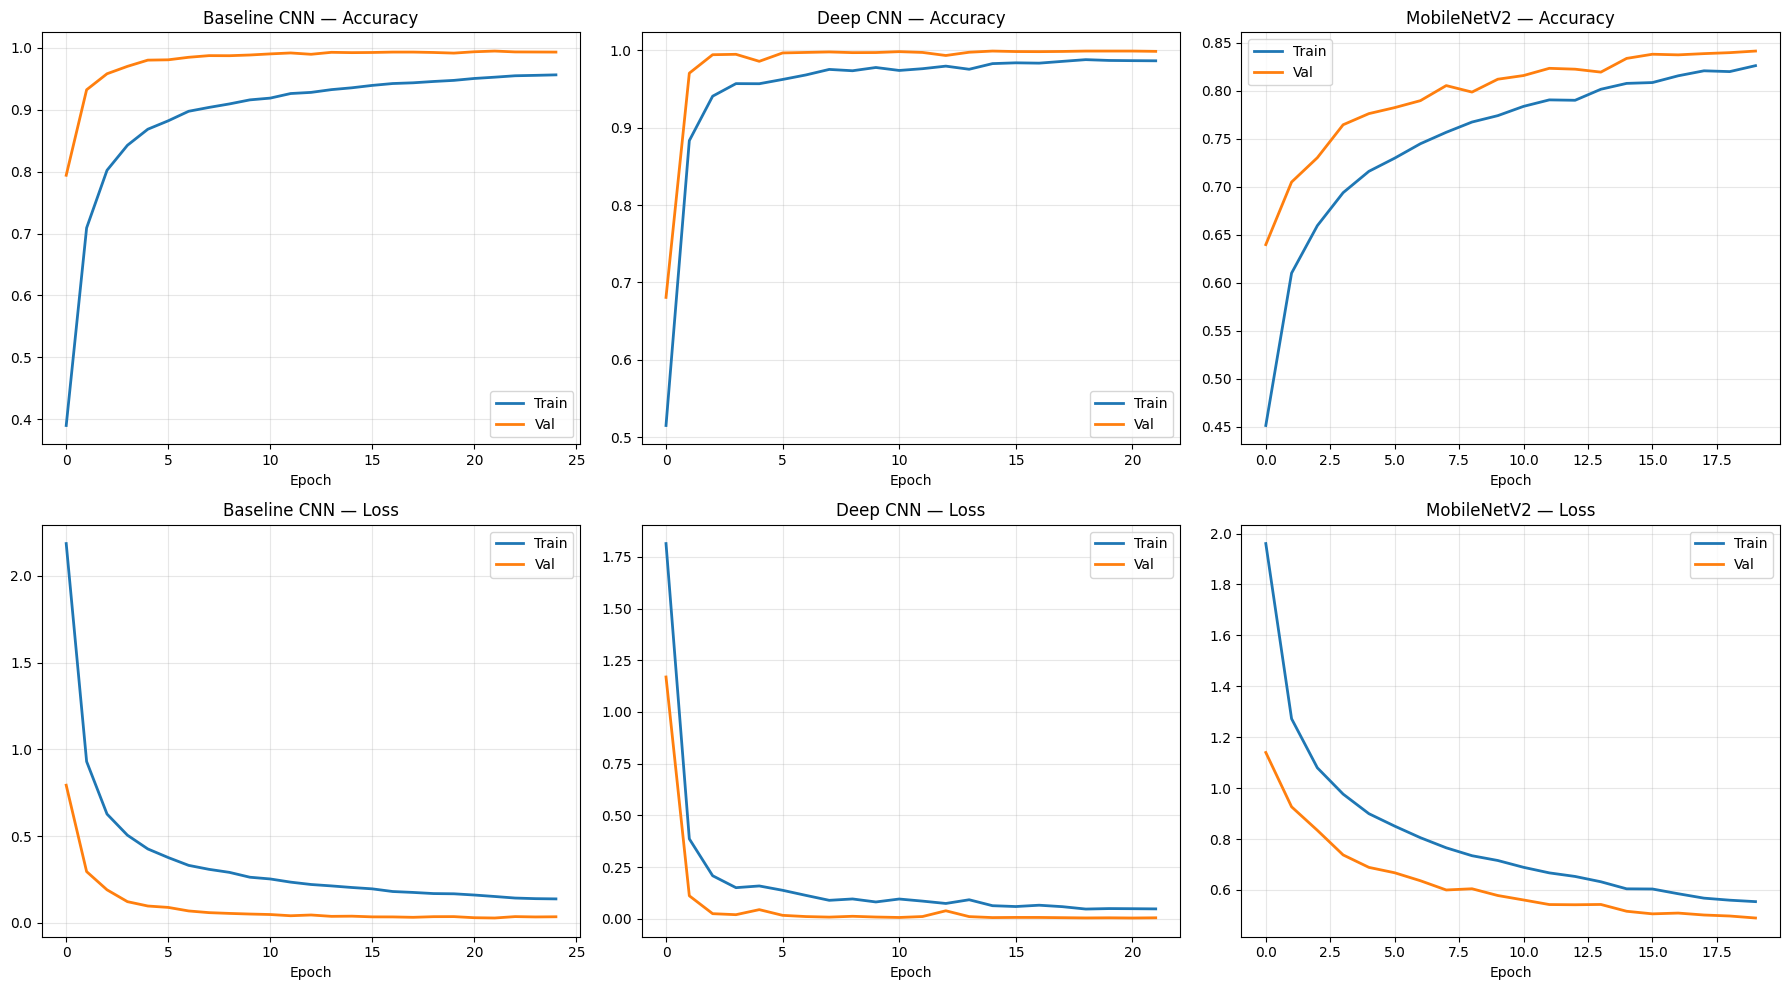

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))
for col, (name, hist) in enumerate([
    ('Baseline CNN', hist_b),
    ('Deep CNN',     hist_d),
    ('MobileNetV2',  hist_m),
]):
    axes[0,col].plot(hist.history['accuracy'],     label='Train', lw=2)
    axes[0,col].plot(hist.history['val_accuracy'], label='Val',   lw=2)
    axes[0,col].set_title(f'{name} — Accuracy')
    axes[0,col].set_xlabel('Epoch'); axes[0,col].legend()
    axes[0,col].grid(True, alpha=0.3)

    axes[1,col].plot(hist.history['loss'],     label='Train', lw=2)
    axes[1,col].plot(hist.history['val_loss'], label='Val',   lw=2)
    axes[1,col].set_title(f'{name} — Loss')
    axes[1,col].set_xlabel('Epoch'); axes[1,col].legend()
    axes[1,col].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 12. Model Comparison

              accuracy         time
Deep CNN      0.982581  5675.300351
Baseline CNN  0.966192  1819.273821
MobileNetV2   0.543705  2346.116774

Best: Deep CNN  (0.9826)


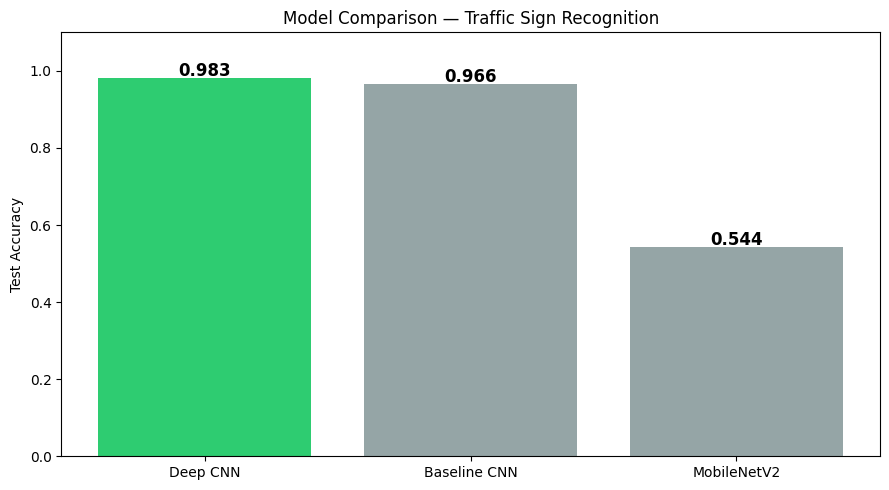

In [19]:
results = {
    'Baseline CNN': {'accuracy': acc_b, 'time': t_b},
    'Deep CNN':     {'accuracy': acc_d, 'time': t_d},
    'MobileNetV2':  {'accuracy': acc_m, 'time': t_m},
}
results_df = pd.DataFrame(results).T.sort_values('accuracy', ascending=False)
BEST_NAME  = results_df.index[0]

print(results_df.to_string())
print(f"\nBest: {BEST_NAME}  ({float(results_df.iloc[0]['accuracy']):.4f})")

plt.figure(figsize=(9,5))
colors = ['#2ecc71' if n==BEST_NAME else '#95a5a6' for n in results_df.index]
bars = plt.bar(results_df.index,
               results_df['accuracy'].astype(float), color=colors)
for bar, v in zip(bars, results_df['accuracy'].astype(float)):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')
plt.ylabel('Test Accuracy')
plt.title('Model Comparison — Traffic Sign Recognition')
plt.ylim(0, 1.1); plt.tight_layout(); plt.show()

## 13. Best Model Evaluation

395/395 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step
Best: Deep CNN  |  Test Acc: 0.9826

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        60
           1       0.99      1.00      0.99       720
           2       0.99      0.99      0.99       750
           3       0.99      0.97      0.98       450
           4       0.99      0.99      0.99       660
           5       0.96      1.00      0.98       630
           6       1.00      0.87      0.93       150
           7       0.98      0.99      0.99       450
           8       0.99      0.98      0.98       450
           9       0.98      1.00      0.99       480
          10       1.00      1.00      1.00       660
          11       0.96      1.00      0.98       420
          12       0.99      0.99      0.99       690
          13       1.00      1.00      1.00       720
          14       1.00      1.00      1.00       270
          15       0.98      0.99      0.98       210
 

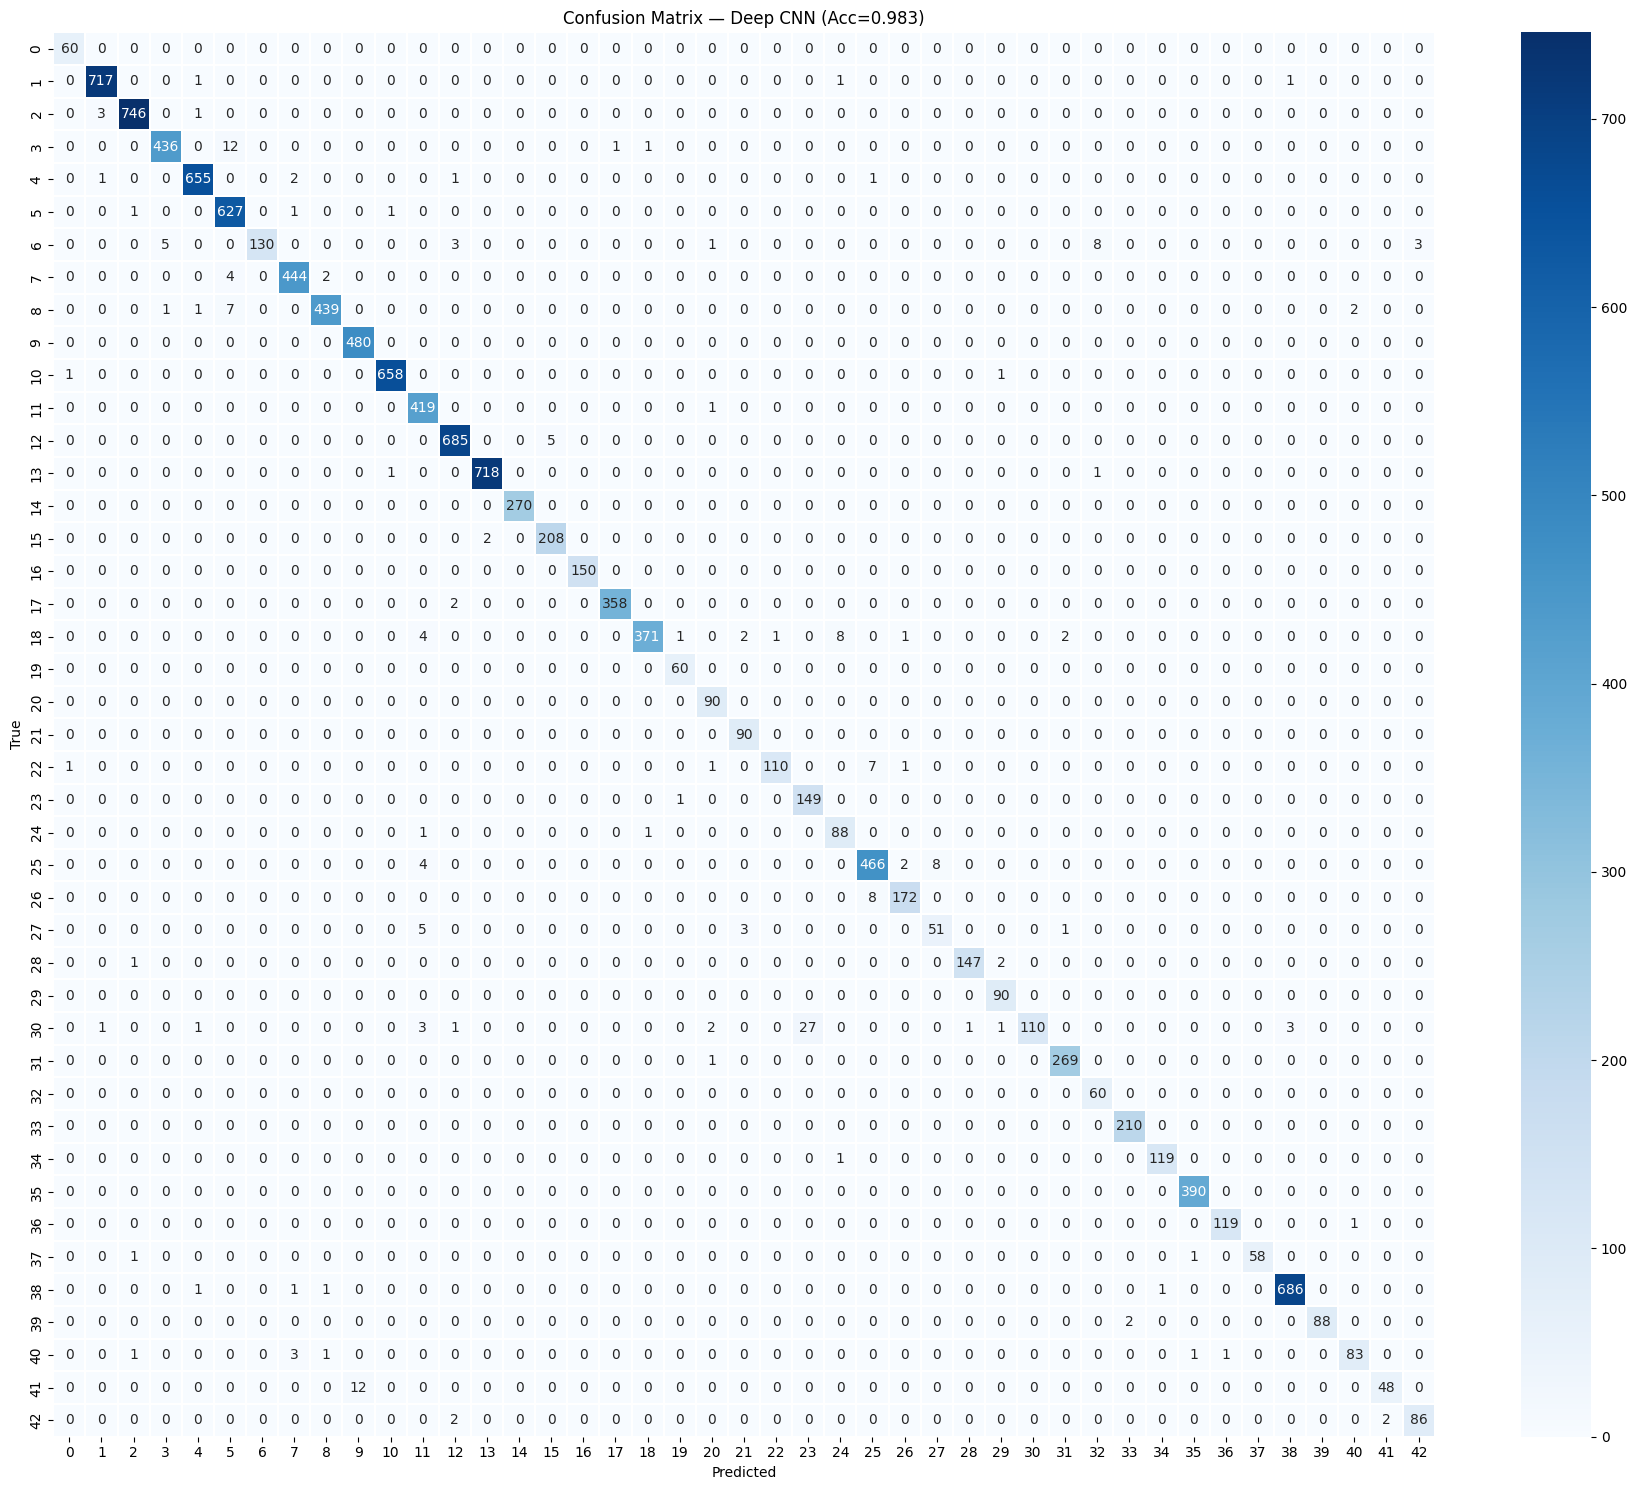

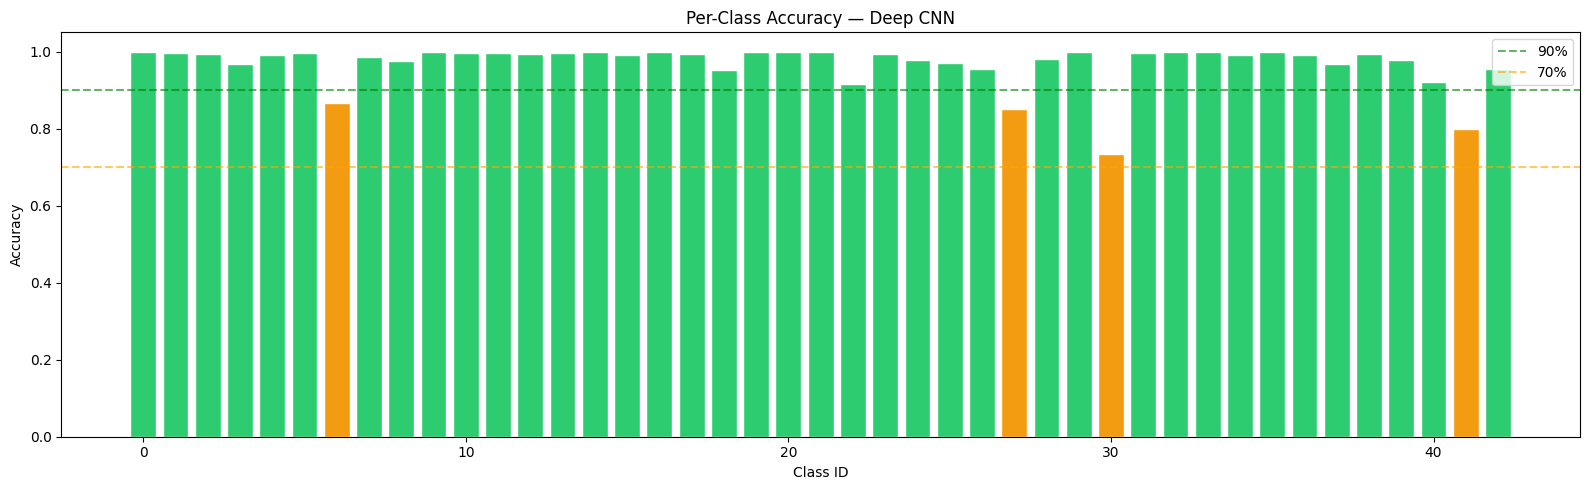

Classes >= 90%: 39/43
Classes <  70%: 0/43
Worst  class  : 30 (0.733)
Best   class  : 0 (1.000)


In [20]:
if BEST_NAME == 'MobileNetV2':
    bm, Xe, ye_cat, ye = mobilenet, X_test48, y_test48_cat, y_test48
elif BEST_NAME == 'Deep CNN':
    bm, Xe, ye_cat, ye = deep,      X_test32, y_test32_cat, y_test32
else:
    bm, Xe, ye_cat, ye = baseline,  X_test32, y_test32_cat, y_test32

y_pred   = np.argmax(bm.predict(Xe), axis=1)
best_acc = results[BEST_NAME]['accuracy']

print(f"Best: {BEST_NAME}  |  Test Acc: {best_acc:.4f}\n")
print(classification_report(ye, y_pred))

cm = confusion_matrix(ye, y_pred)
plt.figure(figsize=(18,15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.3)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title(f'Confusion Matrix — {BEST_NAME} (Acc={best_acc:.3f})')
plt.tight_layout(); plt.show()

per_class = cm.diagonal() / cm.sum(axis=1)
bar_colors = ['#2ecc71' if a>=0.9 else '#f39c12' if a>=0.7 else '#e74c3c'
              for a in per_class]
plt.figure(figsize=(16,5))
plt.bar(range(43), per_class, color=bar_colors, edgecolor='white')
plt.axhline(0.9, color='green',  linestyle='--', alpha=0.6, label='90%')
plt.axhline(0.7, color='orange', linestyle='--', alpha=0.6, label='70%')
plt.xlabel('Class ID'); plt.ylabel('Accuracy')
plt.title(f'Per-Class Accuracy — {BEST_NAME}')
plt.legend(); plt.tight_layout(); plt.show()

print(f"Classes >= 90%: {(per_class>=0.9).sum()}/43")
print(f"Classes <  70%: {(per_class< 0.7).sum()}/43")
print(f"Worst  class  : {per_class.argmin()} ({per_class.min():.3f})")
print(f"Best   class  : {per_class.argmax()} ({per_class.max():.3f})")

## 14. Final Summary

In [21]:
print("=" * 62)
print("   TRAFFIC SIGN RECOGNITION — FINAL SUMMARY")
print("=" * 62)
print("\nDATASET:")
print("  Train: 39,209 | Test: 12,630 | Classes: 43")
print("  Imbalance: class 0 (210) to class 2 (2,250) — 10x ratio")
print("\nMODEL COMPARISON:")
print("-" * 62)
print(f"  {'Model':<20} {'Accuracy':>10} {'Time(s)':>10}")
print("-" * 62)
for n, row in results_df.iterrows():
    mark = ' <-- BEST' if n==BEST_NAME else ''
    print(f"  {n:<20} {float(row['accuracy']):>10.4f} {float(row['time']):>10.1f}{mark}")
print("\nKEY FINDINGS:")
print("  1. tf.data pipeline used — no ImageDataGenerator bug")
print("  2. Horizontal flip disabled — traffic signs are direction-specific")
print("  3. MobileNetV2 uses frozen ImageNet weights + custom head")
print("  4. Augmentation: random brightness + contrast only (version-safe)")
print("  5. Class imbalance (10x) affects lowest-frequency class performance")
print("=" * 62)

   TRAFFIC SIGN RECOGNITION — FINAL SUMMARY

DATASET:
  Train: 39,209 | Test: 12,630 | Classes: 43
  Imbalance: class 0 (210) to class 2 (2,250) — 10x ratio

MODEL COMPARISON:
--------------------------------------------------------------
  Model                  Accuracy    Time(s)
--------------------------------------------------------------
  Deep CNN                 0.9826     5675.3 <-- BEST
  Baseline CNN             0.9662     1819.3
  MobileNetV2              0.5437     2346.1

KEY FINDINGS:
  1. tf.data pipeline used — no ImageDataGenerator bug
  2. Horizontal flip disabled — traffic signs are direction-specific
  3. MobileNetV2 uses frozen ImageNet weights + custom head
  4. Augmentation: random brightness + contrast only (version-safe)
  5. Class imbalance (10x) affects lowest-frequency class performance
